In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/heart.csv")

feature_cols = ["age","sex","cp","trestbps","chol","fbs","restecg",
                "thalach","exang","oldpeak","slope","ca","thal"]
target_col = "target"

X = df[feature_cols]
y = df[target_col].astype(int)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

dl_model = models.Sequential([
    layers.Input(shape=(X_train_sc.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 128 (512.00 B)

In [6]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = dl_model.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6372 - auc: 0.7104 - loss: 0.6588 - val_accuracy: 0.7500 - val_auc: 0.8199 - val_loss: 0.5670
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7957 - auc: 0.8662 - loss: 0.4653 - val_accuracy: 0.7927 - val_auc: 0.8759 - val_loss: 0.4993
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8216 - auc: 0.8979 - loss: 0.4038 - val_accuracy: 0.7988 - val_auc: 0.8937 - val_loss: 0.4539
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8354 - auc: 0.9133 - loss: 0.3715 - val_accuracy: 0.7988 - val_auc: 0.9063 - val_loss: 0.4246
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8430 - auc: 0.9177 - loss: 0.3631 - val_accuracy: 0.8171 - val_auc: 0.9105 - val_loss: 0.4042
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8674 - auc: 0.9257 - loss: 0.3481 - val_accuracy: 0.8293 - val_auc: 0.9189 - val_loss: 0.3867
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7m

In [7]:
from sklearn.metrics import classification_report, roc_auc_score

loss, acc, auc = dl_model.evaluate(X_test_sc, y_test, verbose=0)
print("Test Accuracy:", acc)
print("Test AUC:", auc)

y_prob = dl_model.predict(X_test_sc).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC (sklearn):", roc_auc_score(y_test, y_prob))

Test Accuracy: 1.0
Test AUC: 0.9999999403953552
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

ROC-AUC (sklearn): 1.0


In [8]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


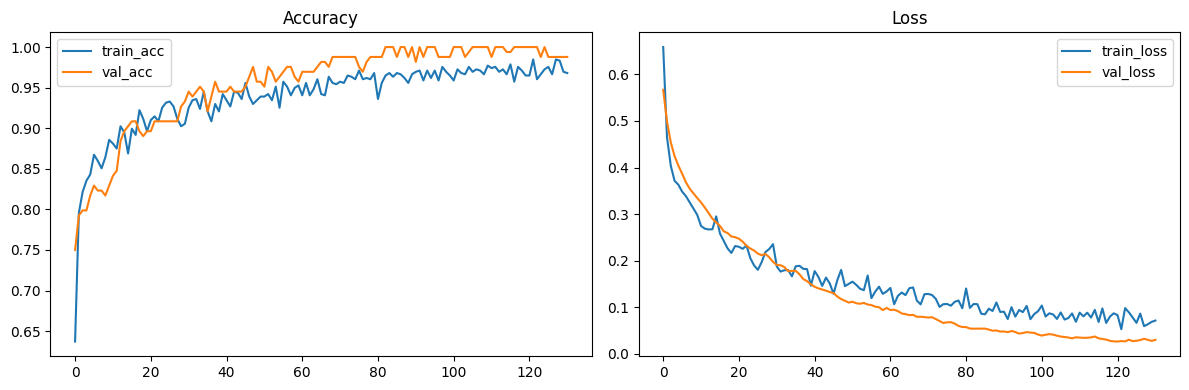

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

dl_model.save("../models/dl_model.keras")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(feature_cols, "../models/feature_cols.pkl")

print("Saved: models/dl_model.keras, models/scaler.pkl, models/feature_cols.pkl")

Saved: models/dl_model.keras, models/scaler.pkl, models/feature_cols.pkl
